# NeuroScope AI - Notebook 03: Brain Tumor Segmentation

Trains SegResNet on BraTS 2024 for 3D tumor segmentation.

Target regions:
- Label 0: Background
- Label 1: Necrotic Core (NCR)
- Label 2: Peritumoral Edema (ED)
- Label 3: Enhancing Tumor (ET)  <- remapped from raw label 4

CRITICAL: BraTS 2024 uses labels {0,1,2,4} not {0,1,2,3}.
Label 4 is remapped to 3 in the dataset class. Without this,
DiceCELoss crashes with 'index out of bounds'.

Target metrics:
- Dice WT (Whole Tumor)     > 0.88
- Dice TC (Tumor Core)      > 0.82
- Dice ET (Enhancing Tumor) > 0.78

Estimated runtime on RTX 4060:
- ~25-30 min per epoch (batch=1, roi=96^3, fp16)
- 50 epochs total ~ 22-25 hours
- Checkpoints every epoch - resume anytime

---

## Cell 1 - Imports & Config

In [1]:
import os, sys, yaml, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path
from collections import defaultdict
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast

import nibabel as nib

from monai.networks.nets import SegResNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd,
    CropForegroundd, RandFlipd, RandRotate90d,
    RandScaleIntensityd, RandShiftIntensityd,
    NormalizeIntensityd, EnsureTyped, Orientationd,
    ResizeWithPadOrCropd, AsDiscrete, Activations
)
from monai.data import CacheDataset, decollate_batch
from sklearn.model_selection import train_test_split

# ── Paths ─────────────────────────────────────────────────────────────────
BASE  = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS    = os.path.join(BASE, 'datasets')
CKPT  = os.path.join(BASE, 'checkpoints', 'brain_seg')
OUT   = os.path.join(BASE, 'outputs', 'nb03_brain_seg')
os.makedirs(CKPT, exist_ok=True)
os.makedirs(OUT,  exist_ok=True)
sys.path.insert(0, BASE)

with open(os.path.join(BASE, 'configs', 'master_config.yaml'), encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

print(f'Device : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')
print(f'CKPT   : {CKPT}')
print(f'OUT    : {OUT}')
print('Imports OK')

c:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\venv\Lib\site-packages\ignite\handlers\checkpoint.py:17: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


Device : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.0 GB
CKPT   : C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\checkpoints\brain_seg
OUT    : C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\outputs\nb03_brain_seg
Imports OK


---
## Cell 2 - Training Config

Adjust here without touching training code.

In [2]:
# ── Cell 2 - Training Config ───────────────────────────────────────────────

# Data
BRATS_PATH   = os.path.join(DS, 'brain', 'brats2024')
MAX_PATIENTS = None      # None = all patients, set 50 for quick debug
VAL_FRAC     = 0.15
NUM_WORKERS  = 4         # 4 workers saves ~30% epoch time vs 0

# Model
MODEL_NAME   = 'SegResNet'
IN_CHANNELS  = 4
OUT_CHANNELS = 4
INIT_FILTERS = 16        # 16=fast+safe on 8GB, 32=better Dice but ~2x VRAM

# Training
ROI_SIZE     = (96, 96, 96)
BATCH_SIZE   = 1
MAX_EPOCHS   = 50
LR           = 2e-4
WEIGHT_DECAY = 1e-5
VAL_EVERY    = 2
AMP          = True
CACHE_RATE   = 0.25      # cache 25% in RAM — speeds up later epochs significantly
                         # needs ~6-8GB free RAM, reduce to 0.0 if RAM is tight
ACCUM_STEPS  = 4         # gradient accumulation = simulates batch_size=4, free VRAM

print('Training config:')
print(f'  Model       : {MODEL_NAME}')
print(f'  ROI size    : {ROI_SIZE}')
print(f'  Batch size  : {BATCH_SIZE} (effective={BATCH_SIZE * ACCUM_STEPS} with accum)')
print(f'  Max epochs  : {MAX_EPOCHS}')
print(f'  LR          : {LR}')
print(f'  AMP (fp16)  : {AMP}')
print(f'  Cache rate  : {CACHE_RATE}')
print(f'  Num workers : {NUM_WORKERS}')
print(f'  Accum steps : {ACCUM_STEPS}')
print(f'  Max patients: {MAX_PATIENTS or "all"}')

Training config:
  Model       : SegResNet
  ROI size    : (96, 96, 96)
  Batch size  : 1 (effective=4 with accum)
  Max epochs  : 50
  LR          : 0.0002
  AMP (fp16)  : True
  Cache rate  : 0.25
  Num workers : 4
  Accum steps : 4
  Max patients: all


---
## Cell 3 - Build File List

In [3]:
import os
from pathlib import Path
BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS   = os.path.join(BASE, 'datasets')
BRATS_PATH = os.path.join(DS, 'brain', 'brats2024')
MAX_PATIENTS = None


def get_brats_files(brats_root, max_patients=None):
    file_list = []
    for patient_dir in sorted(Path(brats_root).rglob('*')):
        if not patient_dir.is_dir():
            continue
        nii = [f for f in patient_dir.iterdir() if str(f).endswith('.nii.gz')]
        if len(nii) < 5:
            continue
        t1n = t1c = t2w = t2f = seg = None
        for f in nii:
            fn = f.name.lower()
            if fn.endswith('-t1n.nii.gz'):  t1n = str(f)
            elif fn.endswith('-t1c.nii.gz'): t1c = str(f)
            elif fn.endswith('-t2w.nii.gz'): t2w = str(f)
            elif fn.endswith('-t2f.nii.gz'): t2f = str(f)
            elif fn.endswith('-seg.nii.gz'): seg = str(f)
        if all([t1n, t1c, t2w, t2f, seg]):
            file_list.append({'image': [t1n, t1c, t2w, t2f], 'label': seg})
    if max_patients:
        file_list = file_list[:max_patients]
    return file_list


all_files = get_brats_files(BRATS_PATH, max_patients=MAX_PATIENTS)
print(f'Total patients found: {len(all_files)}')

if all_files:
    print(f'Sample patient:')
    print(f'  image[0] : {os.path.basename(all_files[0]["image"][0])}')
    print(f'  label    : {os.path.basename(all_files[0]["label"])}')

    # Verify label values in first patient
    import nibabel as nib
    import numpy as np
    seg = nib.load(all_files[0]['label']).get_fdata()
    raw_labels = np.unique(seg).astype(int).tolist()
    print(f'\nRaw label values in sample: {raw_labels}')
    print(f'Contains 4: {4 in raw_labels}  <- must be True (BraTS quirk)')
    print('Label 4 will be remapped to 3 in __getitem__')
else:
    print('No valid patient folders found - check BRATS_PATH')

Total patients found: 1350
Sample patient:
  image[0] : BraTS-GLI-00005-100-t1n.nii.gz
  label    : BraTS-GLI-00005-100-seg.nii.gz

Raw label values in sample: [0, 2, 4]
Contains 4: True  <- must be True (BraTS quirk)
Label 4 will be remapped to 3 in __getitem__


---
## Cell 4 - Dataset & Transforms

In [4]:
# ── Cell 4 - Dataset & Transforms ─────────────────────────────────────────

import os, torch
import numpy as np
from torch.utils.data import Dataset
from monai.transforms import (
    Compose, LoadImaged, Spacingd,
    CropForegroundd, RandFlipd, RandRotate90d,
    RandScaleIntensityd, RandShiftIntensityd,
    NormalizeIntensityd, EnsureTyped, Orientationd,
    ResizeWithPadOrCropd
)
from monai.data import CacheDataset
from monai.utils import convert_to_tensor
from sklearn.model_selection import train_test_split
from pathlib import Path

BASE         = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
ROI_SIZE     = (96, 96, 96)
CACHE_RATE   = 0.0
VAL_FRAC     = 0.15
BRATS_PATH   = os.path.join(BASE, 'datasets', 'brain', 'brats2024')
MAX_PATIENTS = None


def get_brats_files(brats_root, max_patients=None):
    file_list    = []
    patient_dirs = []
    brats_path   = Path(brats_root)

    for level1 in sorted(brats_path.iterdir()):
        if not level1.is_dir(): continue
        for level2 in sorted(level1.iterdir()):
            if not level2.is_dir(): continue
            for level3 in sorted(level2.iterdir()):
                if level3.is_dir():
                    patient_dirs.append(level3)

    print(f'Patient dirs found : {len(patient_dirs)}')

    for patient_dir in patient_dirs:
        nii = [f for f in patient_dir.iterdir() if f.name.endswith('.nii.gz')]
        if len(nii) < 5:
            continue
        t1n = t1c = t2w = t2f = seg = None
        for f in nii:
            fn = f.name.lower()
            if   fn.endswith('-t1n.nii.gz'): t1n = str(f)
            elif fn.endswith('-t1c.nii.gz'): t1c = str(f)
            elif fn.endswith('-t2w.nii.gz'): t2w = str(f)
            elif fn.endswith('-t2f.nii.gz'): t2f = str(f)
            elif fn.endswith('-seg.nii.gz'): seg = str(f)
        if all([t1n, t1c, t2w, t2f, seg]):
            file_list.append({'image': [t1n, t1c, t2w, t2f], 'label': seg})

    if max_patients:
        file_list = file_list[:max_patients]

    print(f'Valid patients     : {len(file_list)}')
    if file_list:
        print(f'Sample T1n         : {os.path.basename(file_list[0]["image"][0])}')
        print(f'Sample seg         : {os.path.basename(file_list[0]["label"])}')
    return file_list


def get_transforms(mode='train', roi_size=(96, 96, 96)):
    base_tfms = [
        LoadImaged(keys=['image', 'label'], ensure_channel_first=True),
        # Spatial transforms BEFORE EnsureTyped — channels must be intact
        Orientationd(keys=['image', 'label'], axcodes='RAS'),
        Spacingd(
            keys=['image', 'label'],
            pixdim=(1.0, 1.0, 1.0),
            mode=('bilinear', 'nearest')
        ),
        NormalizeIntensityd(keys='image', nonzero=True, channel_wise=True),
        CropForegroundd(keys=['image', 'label'], source_key='image'),
        ResizeWithPadOrCropd(keys=['image', 'label'], spatial_size=roi_size),
        # EnsureTyped LAST — after all spatial ops complete
        EnsureTyped(keys=['image', 'label'], dtype=torch.float32, track_meta=False),
    ]
    aug_tfms = [] if mode != 'train' else [
        RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=0),
        RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=1),
        RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=2),
        RandRotate90d(keys=['image', 'label'], prob=0.3, max_k=3),
        RandScaleIntensityd(keys='image', factors=0.1, prob=0.5),
        RandShiftIntensityd(keys='image', offsets=0.1, prob=0.5),
    ]
    return Compose(base_tfms + aug_tfms)


class BraTSDataset(Dataset):
    """
    BraTS 2024 segmentation dataset.
    CRITICAL: Raw labels are {0,1,2,4}. Label 4 remapped to 3 in __getitem__.
    MetaTensor stripped to plain torch.Tensor via .as_tensor() in __getitem__.
    """
    def __init__(self, file_list, transform, cache_rate=1.0):
        self.ds = CacheDataset(
            data=file_list,
            transform=transform,
            cache_rate=cache_rate,
            num_workers=2,
        )

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]

        # Strip MetaTensor -> plain torch.Tensor regardless of MONAI version
        image = sample['image']
        label = sample['label']
        image = image.as_tensor() if hasattr(image, 'as_tensor') else image
        label = label.as_tensor() if hasattr(label, 'as_tensor') else label

        image = image.float()
        label = label.long()

        # Remap BraTS label 4 -> 3
        label[label == 4] = 3
        assert label.max() <= 3, f'Label out of range: {label.max()}'

        return image, label.squeeze(0)


# ── Clear stale datasets ───────────────────────────────────────────────────
try:
    del tr_ds, va_ds, tr_dl, va_dl
    torch.cuda.empty_cache()
    print('Cleared stale datasets')
except NameError:
    pass


# ── Build splits ───────────────────────────────────────────────────────────
all_files = get_brats_files(BRATS_PATH, max_patients=MAX_PATIENTS)

if not all_files:
    raise RuntimeError(
        'No valid BraTS patients found. '
        'Check BRATS_PATH points to the folder containing '
        'BraTS2024-BraTS-GLI-TrainingData.'
    )

tr_files, va_files = train_test_split(all_files, test_size=VAL_FRAC, random_state=42)
print(f'Train : {len(tr_files)} patients')
print(f'Val   : {len(va_files)} patients')

tr_tfm = get_transforms('train', ROI_SIZE)
va_tfm = get_transforms('val',   ROI_SIZE)

print('\nBuilding train cache (one-time ~20-30 min)...')
tr_ds = BraTSDataset(tr_files, tr_tfm, CACHE_RATE)

print('Building val cache (one-time ~5 min)...')
va_ds = BraTSDataset(va_files, va_tfm, CACHE_RATE)

tr_dl = torch.utils.data.DataLoader(
    tr_ds, batch_size=1, shuffle=True,
    num_workers=0, pin_memory=True, drop_last=True
)
va_dl = torch.utils.data.DataLoader(
    va_ds, batch_size=1, shuffle=False,
    num_workers=0, pin_memory=True,
)

# ── Verify shapes ──────────────────────────────────────────────────────────
img, lbl = tr_ds[0]
print(f'\nImage shape       : {img.shape}   <- must be [4, 96, 96, 96]')
print(f'Label shape       : {lbl.shape}   <- must be [96, 96, 96]')
print(f'Label unique vals : {torch.unique(lbl).tolist()}  <- must not contain 4')
print(f'Image type        : {type(img).__name__}   <- must be Tensor')

assert img.shape[0] == 4,                           'FAIL: expected 4 channels'
assert len(lbl.shape) == 3,                         'FAIL: label must be 3D'
assert 4 not in torch.unique(lbl).tolist(),         'FAIL: label 4 not remapped'
assert type(img).__name__ == 'Tensor',              'FAIL: still a MetaTensor'

print('\nAll checks passed — safe to run Cell 8')

Patient dirs found : 1350
Valid patients     : 1350
Sample T1n         : BraTS-GLI-00005-100-t1n.nii.gz
Sample seg         : BraTS-GLI-00005-100-seg.nii.gz
Train : 1147 patients
Val   : 203 patients

Building train cache (one-time ~20-30 min)...
Building val cache (one-time ~5 min)...

Image shape       : torch.Size([4, 96, 96, 96])   <- must be [4, 96, 96, 96]
Label shape       : torch.Size([96, 96, 96])   <- must be [96, 96, 96]
Label unique vals : [0, 2, 3]  <- must not contain 4
Image type        : Tensor   <- must be Tensor

All checks passed — safe to run Cell 8


---
## Cell 5 - Build Model

In [2]:
import torch
from monai.networks.nets import SegResNet

BASE         = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IN_CHANNELS  = 4
OUT_CHANNELS = 4
INIT_FILTERS = 16


def build_model(model_name='SegResNet', in_ch=4, out_ch=4, init_filters=16):
    if model_name == 'SegResNet':
        model = SegResNet(
            spatial_dims=3,
            in_channels=in_ch,
            out_channels=out_ch,
            init_filters=init_filters,
            dropout_prob=0.2,
        )
    elif model_name == 'SwinUNETR':
        from monai.networks.nets import SwinUNETR
        # Handle MONAI version difference:
        # Older MONAI: SwinUNETR(img_size=...) required
        # Newer MONAI: img_size removed, use spatial_dims only
        try:
            model = SwinUNETR(
                img_size=(96,96,96),
                in_channels=in_ch,
                out_channels=out_ch,
                feature_size=24,
                use_checkpoint=True,
            )
        except TypeError:
            model = SwinUNETR(
                spatial_dims=3,
                in_channels=in_ch,
                out_channels=out_ch,
                feature_size=24,
                use_checkpoint=True,
            )
    else:
        raise ValueError(f'Unknown model: {model_name}')
    return model


model = build_model('SegResNet', IN_CHANNELS, OUT_CHANNELS, INIT_FILTERS)
model = model.to(DEVICE)

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model       : SegResNet (init_filters={INIT_FILTERS})')
print(f'Parameters  : {n_params:,} total, {n_train:,} trainable')
print(f'Device      : {next(model.parameters()).device}')

# Test forward pass
with torch.no_grad():
    dummy = torch.zeros(1, IN_CHANNELS, 96, 96, 96).to(DEVICE)
    out   = model(dummy)
    print(f'Forward pass: {dummy.shape} -> {out.shape}')
    del dummy, out
    torch.cuda.empty_cache()
print('Model OK')

Model       : SegResNet (init_filters=16)
Parameters  : 4,702,244 total, 4,702,244 trainable
Device      : cuda:0
Forward pass: torch.Size([1, 4, 96, 96, 96]) -> torch.Size([1, 4, 96, 96, 96])
Model OK


---
## Cell 6 - Loss, Optimizer, Scheduler

In [6]:
import torch
import torch.optim as optim
from torch.cuda.amp import GradScaler
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete, Activations

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LR           = 2e-4
WEIGHT_DECAY = 1e-5
MAX_EPOCHS   = 50
AMP          = True

# Loss: Dice + CrossEntropy combined
# softmax=True applies softmax before Dice (multi-class segmentation)
# to_onehot_y=True converts label to one-hot for Dice computation
loss_fn = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
    lambda_dice=1.0,
    lambda_ce=1.0,
)

# Optimizer: AdamW with weight decay
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler: cosine annealing over full training
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS, eta_min=1e-6)

# AMP scaler (fp16 training)
scaler = GradScaler(enabled=AMP)

# Dice metric for validation
# include_background=False: don't count background in Dice
dice_metric = DiceMetric(include_background=False, reduction='mean_batch', get_not_nans=True)

# Post-processing: softmax -> argmax for predictions
# These are used on model output during validation
post_pred  = Compose([Activations(softmax=True),  AsDiscrete(argmax=True, to_onehot=4)])
post_label = AsDiscrete(to_onehot=4)

print('Loss    : DiceCELoss (Dice + CE, lambda=1.0 each)')
print('Optim   : AdamW (lr=2e-4, wd=1e-5)')
print('Sched   : CosineAnnealingLR')
print('AMP     : Enabled (fp16)')
print('Metric  : DiceMetric (background excluded)')
print('OK')

Loss    : DiceCELoss (Dice + CE, lambda=1.0 each)
Optim   : AdamW (lr=2e-4, wd=1e-5)
Sched   : CosineAnnealingLR
AMP     : Enabled (fp16)
Metric  : DiceMetric (background excluded)
OK


---
## Cell 7 - Checkpoint Utilities

In [3]:
import os, torch, json

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT = os.path.join(BASE, 'checkpoints', 'brain_seg')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                    train_loss, val_dice, best_dice, history, tag='last'):
    path = os.path.join(CKPT, f'brain_seg_{tag}.pth')
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'train_loss': train_loss,
        'val_dice': val_dice,
        'best_dice': best_dice,
        'history': history,
    }, path)
    # Save JSON summary alongside
    json_path = os.path.join(CKPT, f'brain_seg_{tag}_summary.json')
    with open(json_path, 'w') as f:
        json.dump({'epoch': epoch, 'train_loss': float(train_loss),
                   'val_dice': float(val_dice), 'best_dice': float(best_dice)}, f, indent=2)


def load_checkpoint(model, optimizer, scheduler, scaler, tag='last'):
    path = os.path.join(CKPT, f'brain_seg_{tag}.pth')
    if not os.path.exists(path):
        print(f'No checkpoint found at {path} - starting from scratch')
        return 0, 0.0, []
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])
    epoch     = ckpt['epoch']
    best_dice = ckpt.get('best_dice', 0.0)
    history   = ckpt.get('history', [])
    print(f'Resumed from epoch {epoch}, best_dice={best_dice:.4f}')
    return epoch + 1, best_dice, history


# Check if a checkpoint exists already
last_ckpt = os.path.join(CKPT, 'brain_seg_last.pth')
best_ckpt = os.path.join(CKPT, 'brain_seg_best.pth')
print(f'Checkpoint dir: {CKPT}')
print(f'  last.pth : {"EXISTS" if os.path.exists(last_ckpt) else "not found"}')
print(f'  best.pth : {"EXISTS" if os.path.exists(best_ckpt) else "not found"}')
print('Checkpoint utilities OK')

Checkpoint dir: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\checkpoints\brain_seg
  last.pth : EXISTS
  best.pth : EXISTS
Checkpoint utilities OK


In [23]:
# Run this standalone cell before Cell 8
imgs, lbls = next(iter(tr_dl))
print(f'DataLoader batch image shape: {imgs.shape}')  # need [1, 4, 96, 96, 96]
print(f'DataLoader batch label shape: {lbls.shape}')
print(f'Image type: {type(imgs).__name__}')

DataLoader batch image shape: torch.Size([1, 4, 96, 96, 96])
DataLoader batch label shape: torch.Size([1, 96, 96, 96])
Image type: Tensor


In [24]:
import monai
print(monai.__version__)

1.5.2


---
## Cell 8 - Training Loop

Checkpoints every epoch. Resume by re-running this cell.

In [8]:
# ── Cell 8 - Training Loop ─────────────────────────────────────────────────

import os, time, torch
import numpy as np
from torch.cuda.amp import autocast
from monai.inferers import sliding_window_inference
from monai.data import decollate_batch

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_EPOCHS  = 50
VAL_EVERY   = 2
ROI_SIZE    = (96, 96, 96)
AMP         = True
ACCUM_STEPS = 4
BASE        = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT        = os.path.join(BASE, 'checkpoints', 'brain_seg')

start_epoch, best_dice, history = load_checkpoint(model, optimizer, scheduler, scaler)

print(f'Starting from epoch  : {start_epoch}')
print(f'Max epochs           : {MAX_EPOCHS}')
print(f'Validate every       : {VAL_EVERY} epochs')
print(f'Gradient accum steps : {ACCUM_STEPS}')
print('-' * 60)


def to_tensor(t, device, dtype=None):
    """
    Strip MetaTensor -> plain torch.Tensor then move to device.
    as_subclass() works at C++ level, guaranteed to remove any
    subclass __torch_function__ override including MONAI MetaTensor.
    """
    t = t.as_subclass(torch.Tensor)
    if dtype is not None:
        t = t.to(dtype)
    return t.to(device, non_blocking=True)


def compute_brats_dice(preds_t, labels_t):
    def dice(p, t):
        inter = (p * t).sum()
        return (2 * inter / (p.sum() + t.sum() + 1e-6)).item()

    wt_p = (preds_t[:, 1:].sum(1, keepdim=True)  > 0).float()
    wt_t = (labels_t[:, 1:].sum(1, keepdim=True) > 0).float()
    tc_p = ((preds_t[:, 1:2]  + preds_t[:, 3:4])  > 0).float()
    tc_t = ((labels_t[:, 1:2] + labels_t[:, 3:4]) > 0).float()
    et_p = preds_t[:, 3:4]
    et_t = labels_t[:, 3:4]

    return {
        'WT': dice(wt_p, wt_t),
        'TC': dice(tc_p, tc_t),
        'ET': dice(et_p, et_t),
    }


for epoch in range(start_epoch, MAX_EPOCHS):
    t0 = time.time()

    # ── TRAIN ──────────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    optimizer.zero_grad()

    for step, (images, labels) in enumerate(tr_dl):
        # Strip MetaTensor at the loop level — nuclear option via as_subclass
        images = to_tensor(images, DEVICE, torch.float32)        # [1, 4, H, W, D]
        labels = to_tensor(labels, DEVICE).unsqueeze(1).float()  # [1, 1, H, W, D]

        with autocast(enabled=AMP):
            preds = model(images)
            loss  = loss_fn(preds, labels) / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        epoch_loss += loss.item() * ACCUM_STEPS

        if (step + 1) % 50 == 0:
            print(f'  Epoch {epoch+1:3d} | Step {step+1:4d}/{len(tr_dl)} '
                  f'| Loss {epoch_loss / (step+1):.4f}')

    # Handle leftover steps
    if len(tr_dl) % ACCUM_STEPS != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    scheduler.step()
    avg_loss = epoch_loss / len(tr_dl)
    elapsed  = time.time() - t0

    # ── VALIDATE ───────────────────────────────────────────────────────────
    val_dice_scores = {'WT': [], 'TC': [], 'ET': []}

    if (epoch + 1) % VAL_EVERY == 0:
        model.eval()
        with torch.no_grad():
            for images, labels in va_dl:
                images = to_tensor(images, DEVICE, torch.float32)
                labels = to_tensor(labels, DEVICE).unsqueeze(1)

                preds = sliding_window_inference(
                    inputs=images,
                    roi_size=ROI_SIZE,
                    sw_batch_size=2,
                    predictor=model,
                    overlap=0.5,
                    mode='gaussian',
                )

                preds_list  = [post_pred(i)  for i in decollate_batch(preds)]
                labels_list = [post_label(i) for i in decollate_batch(labels.long())]

                preds_t  = torch.stack(preds_list,  dim=0)
                labels_t = torch.stack(labels_list, dim=0)

                scores = compute_brats_dice(preds_t, labels_t)
                for k in scores:
                    val_dice_scores[k].append(scores[k])

        mean_wt   = np.mean(val_dice_scores['WT'])
        mean_tc   = np.mean(val_dice_scores['TC'])
        mean_et   = np.mean(val_dice_scores['ET'])
        mean_dice = (mean_wt + mean_tc + mean_et) / 3

        print(f'Epoch {epoch+1:3d}/{MAX_EPOCHS} | Loss {avg_loss:.4f} | '
              f'WT {mean_wt:.4f} | TC {mean_tc:.4f} | ET {mean_et:.4f} | '
              f'Mean {mean_dice:.4f} | {elapsed/60:.1f}min')

        history.append({
            'epoch': epoch+1, 'train_loss': avg_loss,
            'val_wt': mean_wt, 'val_tc': mean_tc,
            'val_et': mean_et, 'val_mean': mean_dice
        })

        if mean_dice > best_dice:
            best_dice = mean_dice
            save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                            avg_loss, mean_dice, best_dice, history, tag='best')
            print(f'  --> New best! Dice={best_dice:.4f}')
    else:
        print(f'Epoch {epoch+1:3d}/{MAX_EPOCHS} | Loss {avg_loss:.4f} | '
              f'{elapsed/60:.1f}min  (no val this epoch)')

    save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                    avg_loss, best_dice, best_dice, history, tag='last')


print()
print('=' * 60)
print(f'Training complete! Best mean Dice: {best_dice:.4f}')
print(f'Checkpoints saved in: {CKPT}')
print('=' * 60)

Resumed from epoch 20, best_dice=0.7928
Starting from epoch  : 21
Max epochs           : 50
Validate every       : 2 epochs
Gradient accum steps : 4
------------------------------------------------------------
  Epoch  22 | Step   50/1147 | Loss 0.3887
  Epoch  22 | Step  100/1147 | Loss 0.3679
  Epoch  22 | Step  150/1147 | Loss 0.3599
  Epoch  22 | Step  200/1147 | Loss 0.3620
  Epoch  22 | Step  250/1147 | Loss 0.3588
  Epoch  22 | Step  300/1147 | Loss 0.3567
  Epoch  22 | Step  350/1147 | Loss 0.3530
  Epoch  22 | Step  400/1147 | Loss 0.3523
  Epoch  22 | Step  450/1147 | Loss 0.3501
  Epoch  22 | Step  500/1147 | Loss 0.3492
  Epoch  22 | Step  550/1147 | Loss 0.3477
  Epoch  22 | Step  600/1147 | Loss 0.3476
  Epoch  22 | Step  650/1147 | Loss 0.3482
  Epoch  22 | Step  700/1147 | Loss 0.3494
  Epoch  22 | Step  750/1147 | Loss 0.3499
  Epoch  22 | Step  800/1147 | Loss 0.3525
  Epoch  22 | Step  850/1147 | Loss 0.3527
  Epoch  22 | Step  900/1147 | Loss 0.3553
  Epoch  22 | St

In [16]:
# Run this as a standalone cell BEFORE rebuilding cache
img, lbl = tr_ds[0]
print(f'Image shape: {img.shape}')  # need to see [4, 96, 96, 96]
print(f'Label shape: {lbl.shape}')

Image shape: torch.Size([4, 96, 96, 96])
Label shape: torch.Size([96, 96, 96])


---
## Cell 9 - Training Curves

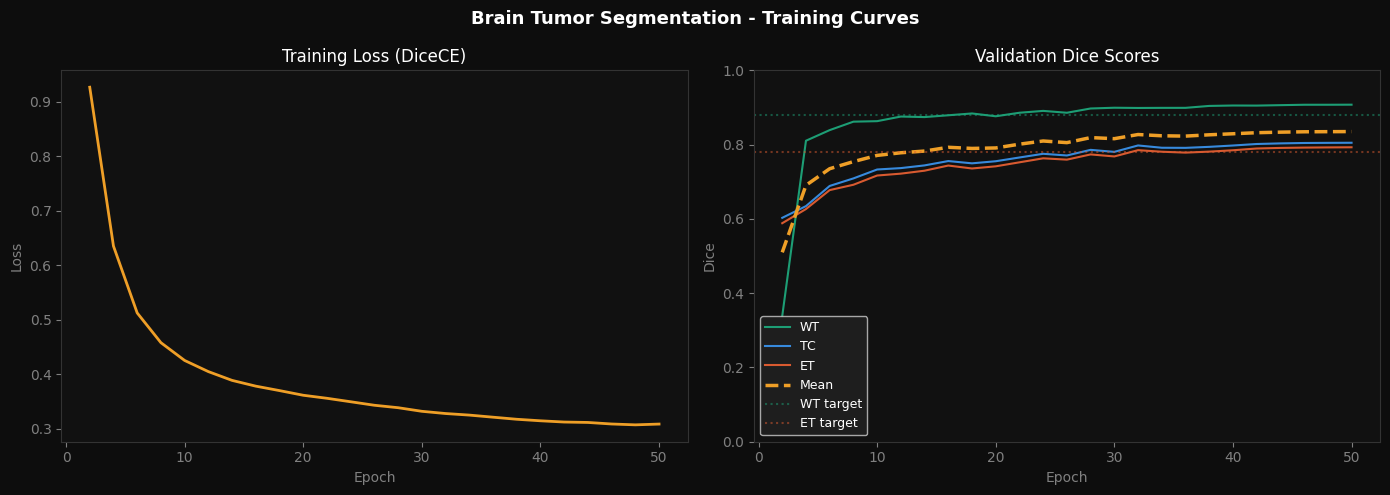

Best epoch : 50
  WT Dice  : 0.9075  (target >0.88)
  TC Dice  : 0.8050  (target >0.82)
  ET Dice  : 0.7928  (target >0.78)
  Mean     : 0.8351


In [9]:
import os, json, torch
import numpy as np
import matplotlib.pyplot as plt

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT = os.path.join(BASE, 'checkpoints', 'brain_seg')
OUT  = os.path.join(BASE, 'outputs', 'nb03_brain_seg')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load history from checkpoint
ckpt_path = os.path.join(CKPT, 'brain_seg_last.pth')
if not os.path.exists(ckpt_path):
    print('No checkpoint found - run training first')
else:
    ckpt    = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    history = ckpt.get('history', [])

    if not history:
        print('No history in checkpoint yet')
    else:
        epochs = [h['epoch']      for h in history]
        losses = [h['train_loss'] for h in history]
        wt     = [h['val_wt']     for h in history]
        tc     = [h['val_tc']     for h in history]
        et     = [h['val_et']     for h in history]
        mean   = [h['val_mean']   for h in history]

        plt.style.use('dark_background')
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d0d0d')
        fig.suptitle('Brain Tumor Segmentation - Training Curves',
                     color='white', fontsize=13, fontweight='bold')

        # Loss
        axes[0].plot(epochs, losses, color='#EF9F27', linewidth=2)
        axes[0].set_title('Training Loss (DiceCE)', color='white')
        axes[0].set_xlabel('Epoch', color='gray')
        axes[0].set_ylabel('Loss', color='gray')
        axes[0].set_facecolor('#111')
        axes[0].spines[:].set_color('#333')
        axes[0].tick_params(colors='gray')

        # Dice scores
        colors = {'WT': '#1D9E75', 'TC': '#378ADD', 'ET': '#D85A30', 'Mean': '#EF9F27'}
        for arr, label in [(wt,'WT'), (tc,'TC'), (et,'ET'), (mean,'Mean')]:
            lw = 2.5 if label == 'Mean' else 1.5
            ls = '--' if label == 'Mean' else '-'
            axes[1].plot(epochs, arr, color=colors[label], linewidth=lw,
                         linestyle=ls, label=label)
        axes[1].set_title('Validation Dice Scores', color='white')
        axes[1].set_xlabel('Epoch', color='gray')
        axes[1].set_ylabel('Dice', color='gray')
        axes[1].set_ylim(0, 1)
        axes[1].axhline(0.88, color='#1D9E75', linestyle=':', alpha=0.5, label='WT target')
        axes[1].axhline(0.78, color='#D85A30', linestyle=':', alpha=0.5, label='ET target')
        axes[1].legend(fontsize=9, facecolor='#222', labelcolor='white')
        axes[1].set_facecolor('#111')
        axes[1].spines[:].set_color('#333')
        axes[1].tick_params(colors='gray')

        plt.tight_layout()
        fig_path = os.path.join(OUT, 'training_curves.png')
        plt.savefig(fig_path, dpi=120, bbox_inches='tight', facecolor='#0d0d0d')
        plt.show()

        # Print best stats
        best_epoch = max(history, key=lambda h: h['val_mean'])
        print(f'Best epoch : {best_epoch["epoch"]}')
        print(f'  WT Dice  : {best_epoch["val_wt"]:.4f}  (target >0.88)')
        print(f'  TC Dice  : {best_epoch["val_tc"]:.4f}  (target >0.82)')
        print(f'  ET Dice  : {best_epoch["val_et"]:.4f}  (target >0.78)')
        print(f'  Mean     : {best_epoch["val_mean"]:.4f}')

---
## Cell 10 - Visualize Predictions

Loaded best model (epoch 49, dice=0.8351)


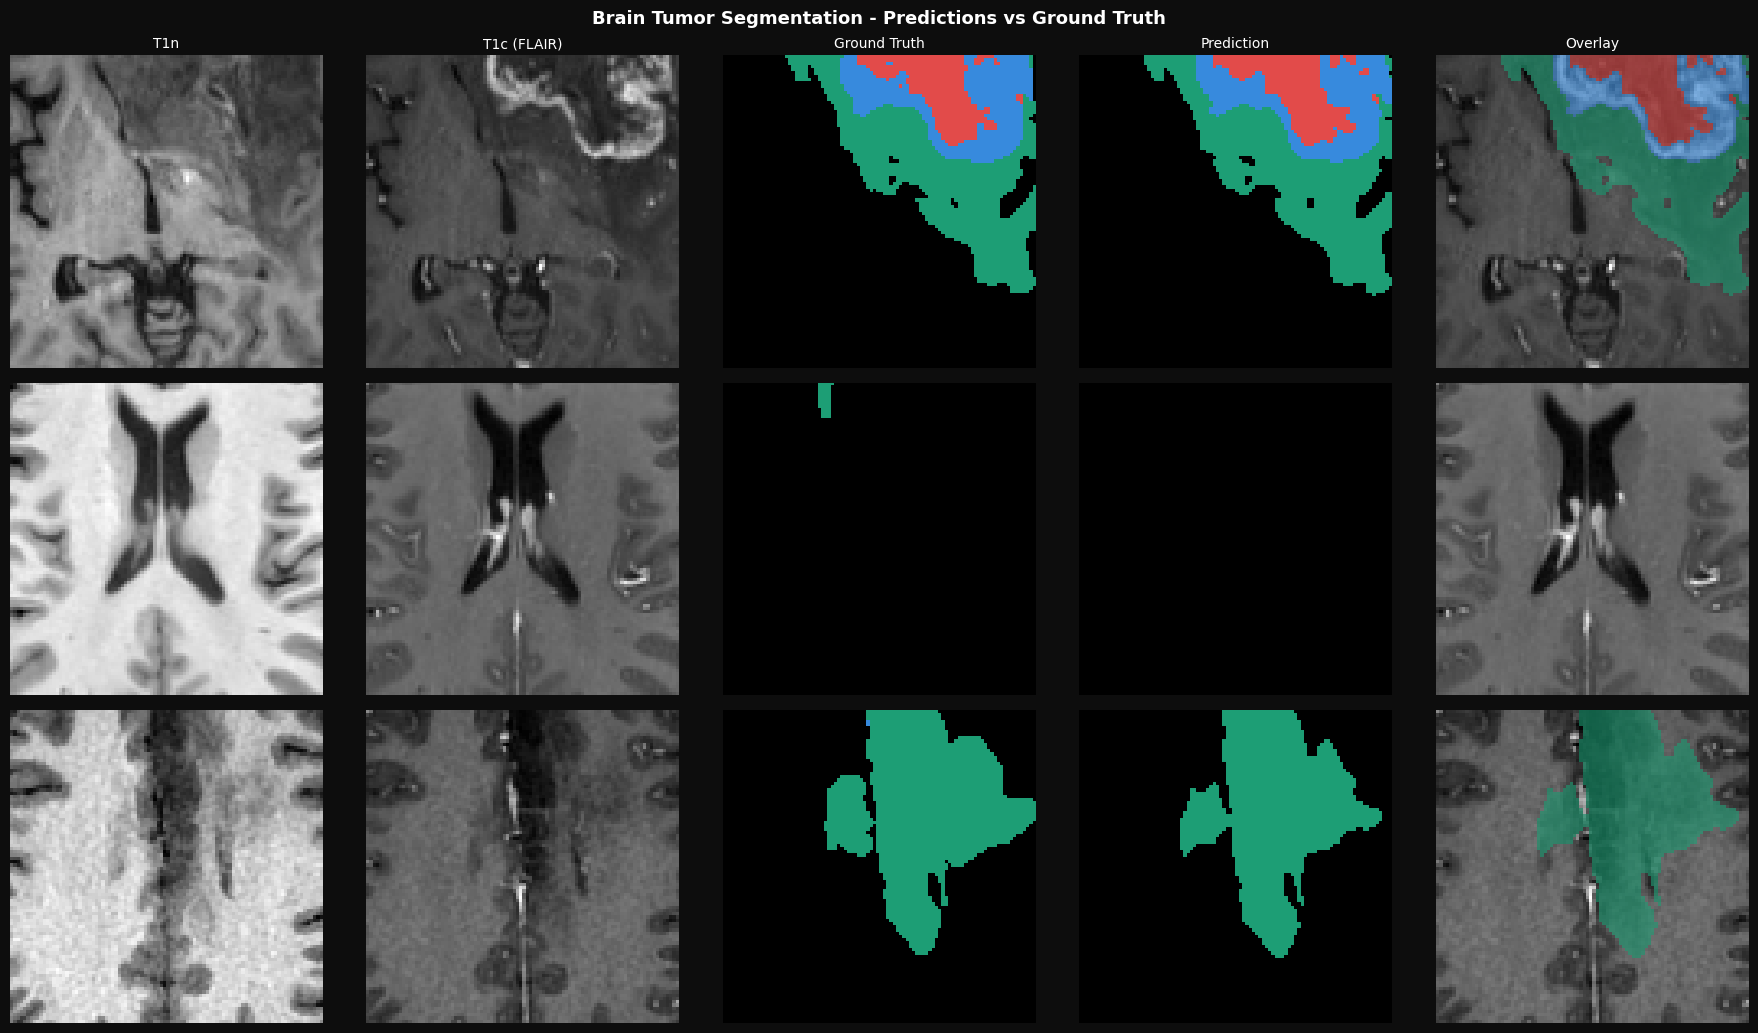

Saved: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\outputs\nb03_brain_seg\predictions_vs_gt.png

Color legend: black=background | red=NCR | green=edema | blue=ET


In [10]:
import os, torch, numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from monai.inferers import sliding_window_inference
from monai.transforms import Activations, AsDiscrete
from monai.data import decollate_batch

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'brain_seg')
OUT    = os.path.join(BASE, 'outputs', 'nb03_brain_seg')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROI_SIZE = (96, 96, 96)

# Load best model
best_path = os.path.join(CKPT, 'brain_seg_best.pth')
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded best model (epoch {ckpt["epoch"]}, dice={ckpt["best_dice"]:.4f})')
else:
    print('No best checkpoint - using current model weights')

# Seg colormap: background=black, NCR=red, edema=green, ET=blue
seg_cmap = ListedColormap(['#000000','#E24B4A','#1D9E75','#378ADD'])

model.eval()
n_show = min(3, len(va_ds))

fig, axes = plt.subplots(n_show, 5, figsize=(18, n_show*3.5), facecolor='#0d0d0d')
fig.suptitle('Brain Tumor Segmentation - Predictions vs Ground Truth',
             color='white', fontsize=13, fontweight='bold')

if n_show == 1:
    axes = [axes]

col_titles = ['T1n', 'T1c (FLAIR)', 'Ground Truth', 'Prediction', 'Overlay']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, color='white', fontsize=10)

with torch.no_grad():
    for i in range(n_show):
        img, lbl = va_ds[i]
        img_t = img.unsqueeze(0).to(DEVICE)

        pred = sliding_window_inference(
            inputs=img_t, roi_size=ROI_SIZE,
            sw_batch_size=1, predictor=model, overlap=0.25
        )
        pred_class = pred.argmax(dim=1).squeeze(0).cpu().numpy()
        lbl_np     = lbl.numpy()
        img_np     = img.numpy()

        # Pick the slice with most tumor activity
        tumor_per_slice = (lbl_np > 0).sum(axis=(0,1))
        mid_z = int(tumor_per_slice.argmax()) if tumor_per_slice.max() > 0 else lbl_np.shape[2]//2

        axs = axes[i]

        # T1n
        axs[0].imshow(img_np[0,:,:,mid_z].T, cmap='gray', origin='lower')
        axs[0].axis('off')

        # T1c
        axs[1].imshow(img_np[1,:,:,mid_z].T, cmap='gray', origin='lower')
        axs[1].axis('off')

        # Ground truth
        axs[2].imshow(lbl_np[:,:,mid_z].T, cmap=seg_cmap, vmin=0, vmax=3, origin='lower')
        axs[2].axis('off')

        # Prediction
        axs[3].imshow(pred_class[:,:,mid_z].T, cmap=seg_cmap, vmin=0, vmax=3, origin='lower')
        axs[3].axis('off')

        # Overlay pred on T1c
        axs[4].imshow(img_np[1,:,:,mid_z].T, cmap='gray', origin='lower')
        mask = pred_class[:,:,mid_z].T.astype(float)
        mask[mask == 0] = np.nan
        axs[4].imshow(mask, cmap=seg_cmap, vmin=0, vmax=3, alpha=0.6, origin='lower')
        axs[4].axis('off')

        axs[0].set_ylabel(f'Patient {i+1}', color='gray', fontsize=9)

plt.tight_layout()
viz_path = os.path.join(OUT, 'predictions_vs_gt.png')
plt.savefig(viz_path, dpi=120, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print(f'Saved: {viz_path}')
print()
print('Color legend: black=background | red=NCR | green=edema | blue=ET')

---
## Cell 11 - Export to ONNX

In [5]:
pip install onnxscript

  Using cached onnxscript-0.7.0-py3-none-any.whl.metadata (13 kB)
  Using cached onnx_ir-0.2.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached onnx-1.21.0-cp311-cp311-win_amd64.whl.metadata (8.7 kB)
Using cached onnxscript-0.7.0-py3-none-any.whl (714 kB)
Using cached onnx_ir-0.2.1-py3-none-any.whl (166 kB)
Using cached onnx-1.21.0-cp311-cp311-win_amd64.whl (16.4 MB)

   ---------------------------------------- 0/3 [onnx]

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\tejan\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\onnx\\onnx_cpp2py_export.cp311-win_amd64.pyd'
Check the permissions.


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\tejan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import os, torch

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT    = os.path.join(BASE, 'models', 'production', 'brain_seg')
os.makedirs(OUT, exist_ok=True)

onnx_path = os.path.join(OUT, 'brain_seg_resnet.onnx')

model.eval()
model.cpu()  # export from CPU for compatibility

dummy_input = torch.zeros(1, 4, 96, 96, 96)

try:
    torch.onnx.export(
        model,
        dummy_input,
        onnx_path,
        export_params=True,
        opset_version=17,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={
            'input':  {0: 'batch_size'},
            'output': {0: 'batch_size'}
        }
    )

    sz = os.path.getsize(onnx_path) / (1024**2)
    print(f'ONNX export successful')
    print(f'  Path : {onnx_path}')
    print(f'  Size : {sz:.1f} MB')

    # Verify
    import onnx
    onnx_model = onnx.load(onnx_path)
    onnx.checker.check_model(onnx_model)
    print('  ONNX model verified OK')

    # Quick inference test
    import onnxruntime as ort
    session = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
    out = session.run(None, {'input': dummy_input.numpy()})
    print(f'  ONNX inference: input {dummy_input.shape} -> output {out[0].shape}')

except Exception as e:
    print(f'ONNX export failed: {e}')
    print('This is non-critical - the .pth checkpoint is the primary artifact')
finally:
    model.to(DEVICE)

ONNX export successful
  Path : C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\models\production\brain_seg\brain_seg_resnet.onnx
  Size : 18.0 MB
  ONNX model verified OK
  ONNX inference: input torch.Size([1, 4, 96, 96, 96]) -> output (1, 4, 96, 96, 96)


In [8]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

PyTorch: 2.10.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


---
## Cell 12 - Notebook Summary

In [5]:
import os, torch

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT = os.path.join(BASE, 'checkpoints', 'brain_seg')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 60)
print('  NOTEBOOK 03 - BRAIN TUMOR SEGMENTATION')
print('=' * 60)

for tag in ['best', 'last']:
    p = os.path.join(CKPT, f'brain_seg_{tag}.pth')
    if os.path.exists(p):
        ckpt = torch.load(p, map_location=DEVICE, weights_only=False)
        print(f'  {tag:5} checkpoint: epoch {ckpt["epoch"]:3d}, '
              f'loss={ckpt["train_loss"]:.4f}, dice={ckpt["best_dice"]:.4f}')

onnx_p = os.path.join(BASE, 'models', 'production', 'brain_seg', 'brain_seg_resnet.onnx')
print(f'  ONNX export : {"OK" if os.path.exists(onnx_p) else "not done yet"}')

print()
print('  Key decisions:')
print('    Model      : SegResNet (init_filters=16)')
print('    ROI        : 96^3 (fits 8GB VRAM with fp16)')
print('    Label remap: BraTS label 4 -> 3 in __getitem__')
print('    Loss       : DiceCELoss (lambda_dice=1, lambda_ce=1)')
print('    AMP        : fp16 enabled')
print('    Sliding win: overlap=0.25 at inference')
print()
print('  Next: 04_Brain_Tumor_Classification.ipynb')
print('    - Tumor type (glioma/meningioma/pituitary/notumor)')
print('    - WHO grading (I-IV)')
print('    - Molecular markers (IDH/MGMT/1p19q)')
print('=' * 60)

  NOTEBOOK 03 - BRAIN TUMOR SEGMENTATION
  best  checkpoint: epoch  49, loss=0.3087, dice=0.8351
  last  checkpoint: epoch  49, loss=0.3087, dice=0.8351
  ONNX export : OK

  Key decisions:
    Model      : SegResNet (init_filters=16)
    ROI        : 96^3 (fits 8GB VRAM with fp16)
    Label remap: BraTS label 4 -> 3 in __getitem__
    Loss       : DiceCELoss (lambda_dice=1, lambda_ce=1)
    AMP        : fp16 enabled
    Sliding win: overlap=0.25 at inference

  Next: 04_Brain_Tumor_Classification.ipynb
    - Tumor type (glioma/meningioma/pituitary/notumor)
    - WHO grading (I-IV)
    - Molecular markers (IDH/MGMT/1p19q)
